# Présentation PRISMA

In [ ]:
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 130,
        "lines.linewidth": 1.6,
    }
)

import src.core.conventions as conv
from src.core.kinematics import CanonicalTwoAxis

kin = CanonicalTwoAxis(n_axes=2)

## 1. Régime de Stokes & modèle Suramorti

### 1.1 La force de traînée de Stokes

Lorsqu'un corps sphérique se déplace au sein d'un fluide visqueux, le fluide exerce une résistance opposée au mouvement, appelée **force de traînée**.

* **À haute vitesse / faible viscosité :**
  $$F_d \propto v^2$$

* **À très faible vitesse / forte viscosité :**
  $$\vec{F}_{\text{Stokes}} = -6 \pi \mu R \, \vec{v}$$
> C'est la loi de traînée établie analytiquement par George Stoke. 

Où :
* $\mu$ est la viscosité dynamique du milieu ($\text{Pa}\cdot\text{s}$),
* $R$ est le rayon de la bille sphérique ($\text{m}$),
* $\vec{v}$ représente la vitesse relative de la bille par rapport au fluide ($\text{m}\cdot\text{s}^{-1}$).


### 1.2 Le nombre de Reynolds particulaire ($Re_p$)

($Re_p$) quantifie le rapport sans dimension entre les forces d'inertie du fluide et les forces de cisaillement visqueux appliquées sur la sphère :

$$Re_p = \frac{\rho_f \, v \, (2R)}{\mu} = \frac{\text{Forces d'inertie}}{\text{Forces visqueuses}}$$

* **$Re_p \gg 1$ :** Les effets inertiels dominent ; la loi de Stokes n'est plus applicable.
* **$Re_p \ll 1$ :** L'hypothèse d'écoulement de Stokes est pleinement satisfaite.

### 1.3 Justification du modèle suramorti ($v = v_{\text{limit}}$)

Dans le repère accéléré lié à la chambre de culture en rotation, l'équation fondamentale de la dynamique appliquée à la bille s'écrit :

$$m^* \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} = \vec{F}_{\text{ext}} - 6 \pi \mu R \, \vec{v}$$

avec :
* $m^* = V_p \left( \rho_p + \frac{1}{2}\rho_f \right)$ la masse effective (masse propre $+$ masse ajoutée),
* $\vec{F}_{\text{ext}}$ la résultante des forces motrices apparentes (poussée d'Archimède / gravité apparente, force centrifuge, force d'Euler).

En divisant par le coefficient de frottement $6 \pi \mu R$, on fait apparaître le **temps de relaxation visqueux** $\tau_v$ :

$$\tau_v \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} + \vec{v} = \vec{v}_{\text{limit}}$$

avec :

$$\tau_v = \frac{m^*}{6 \pi \mu R} = \frac{2}{9} \frac{R^2 \left(\rho_p + \frac{1}{2}\rho_f\right)}{\mu} \approx 3{,}2 \times 10^{-3}\text{ s} \quad (3{,}2\text{ ms})$$

### 1.4 Conclusion physique

Le temps de réponse inertiel de la particule ($\tau_v \approx 3\text{ ms}$) est **infiniment plus court** que l'échelle de temps de variation cinématique de la machine (les rotations complètes de la RPM s'effectuent sur plusieurs secondes).

L'accélération propre $\tau_v \frac{\mathrm{d}\vec{v}}{\mathrm{d}t}$ est donc amortie de façon quasi-instantanée :
$$\tau_v \frac{\mathrm{d}\vec{v}}{\mathrm{d}t} \approx \vec{0} \implies \vec{v}(t) \approx \vec{v}_{\text{limit}}(t) = \tau_v \beta \left( \vec{g}_b - \vec{\omega} \times (\vec{\omega} \times \vec{r}) - \dot{\vec{\omega}} \times \vec{r} \right)$$

Il n'est donc pas nécessaire d'intégrer une équation différentielle du second ordre en vitesse ; l'intégration cinématique directe du premier ordre via RK4 sur $\vec{v}_{\text{limit}}$ est exacte et justifiée.


In [6]:
# ==========================================
# 1. PARAMÈTRES PHYSIQUES DU MILIEU & PARTICULE
# ==========================================
rho_p = 1.202e3     # Densité particule (kg/m^3)
rho_f = 1.200e3     # Densité fluide (kg/m^3)
radius = 0.15e-2    # Rayon bille (1.5 mm)
mu = 1.412          # Viscosité dynamique Glycérol (Pa·s)

V_p = (4.0 / 3.0) * np.pi * radius**3
m_p = rho_p * V_p
denom = rho_p + 0.5 * rho_f

tau_v = (2.0 / 9.0) * (radius**2 * denom) / mu
beta = (rho_p - rho_f) / denom
gamma = rho_p / denom

print(
    f"Paramètres validés : tau_v = {tau_v * 1e3:.2f} ms | beta = {beta:.3e} | gamma = {gamma:.3f}"
)


# ==========================================
# 2. FONCTIONS CINÉMATIQUES & INTÉGRATION RK4
# ==========================================
def compute_kinematics(theta1, theta2, timestamp):
    angles = np.array([theta1, theta2]).T
    rot = kin.rotation(angles)
    g_pos = rot.apply(conv.G_LAB)

    omega1 = np.gradient(theta1, timestamp)
    omega2 = np.gradient(theta2, timestamp)

    Omega_r2 = np.array(
        [-omega2 * np.sin(theta1), omega2 * np.cos(theta1), omega1]
    )

    Omega_r2_diff = np.gradient(Omega_r2, timestamp, axis=1)
    return g_pos, Omega_r2, Omega_r2_diff


def v_limit(r, g_b, omega, omega_dot):
    centrifugal = np.cross(omega, np.cross(omega, r))
    euler = np.cross(omega_dot, r)
    return tau_v * beta * (g_b - centrifugal - euler)


def simulate_trajectory(csv_path, x_0=np.array([0.0, 0.0, 5e-3])):
    """Charge un CSV et intègre la trajectoire en régime suramorti."""
    df = pd.read_csv(csv_path, comment="#")
    timestamp = df["timestamp"].to_numpy()
    theta1 = df["theta1"].to_numpy()
    theta2 = df["theta2"].to_numpy()

    dt = timestamp[1] - timestamp[0]
    N = len(timestamp)

    g_pos, Omega_r2, Omega_r2_diff = compute_kinematics(
        theta1, theta2, timestamp
    )

    r_t = np.zeros((N, 3))
    r_t[0] = x_0

    for n in range(N - 1):
        g_n, g_next = g_pos[n], g_pos[n + 1]
        w_n, w_next = Omega_r2[:, n], Omega_r2[:, n + 1]
        dw_n, dw_next = Omega_r2_diff[:, n], Omega_r2_diff[:, n + 1]

        g_mid = 0.5 * (g_n + g_next)
        w_mid = 0.5 * (w_n + w_next)
        dw_mid = 0.5 * (dw_n + dw_next)

        rn = r_t[n]
        k1 = v_limit(rn, g_n, w_n, dw_n)
        k2 = v_limit(rn + 0.5 * dt * k1, g_mid, w_mid, dw_mid)
        k3 = v_limit(rn + 0.5 * dt * k2, g_mid, w_mid, dw_mid)
        k4 = v_limit(rn + dt * k3, g_next, w_next, dw_next)

        r_t[n + 1] = rn + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    # Calcul dynamique des grandeurs dérivées
    v_t = np.gradient(r_t, dt, axis=0)
    v_norm = np.linalg.norm(v_t, axis=1)
    re_p = (2.0 * radius * rho_f * v_norm) / mu

    return {
        "time": timestamp,
        "theta1": theta1,
        "theta2": theta2,
        "r": r_t,
        "v": v_t,
        "v_norm": v_norm,
        "re_p": re_p,
    }

Paramètres validés : tau_v = 0.64 ms | beta = 1.110e-03 | gamma = 0.667


In [14]:
traj_configs = [
    {
        "file": "../data/trajectories/traj1_inner_zero.csv",
        "title": "Trajectoire 1 : Clinostat (Inner=0, Outer constant)",
    },
    {
        "file": "../data/trajectories/traj2_biaxial_harmonic.csv",
        "title": "Trajectoire 2 : Harmonique biaxiale (Leguy et al.)",
    },
    {
        "file": "../data/trajectories/traj3_biaxial_desynchro.csv",
        "title": "Trajectoire 3 : Désynchronisée (Microgravité simulée)",
    },
]

results = {}
for cfg in traj_configs:
    path = Path(cfg["file"])
    if path.exists():
        print(f"Simulation : {cfg['title']}...")
        res = simulate_trajectory(path)
        results[cfg["title"]] = res
        print(
            f"  -> Déplacement total : {np.linalg.norm(res['r'][-1] - res['r'][0])*1e3:.3f} mm"
        )
        print(f"  -> Re_p maximal     : {np.max(res['re_p']):.3e}")

Simulation : Trajectoire 1 : Clinostat (Inner=0, Outer constant)...
  -> Déplacement total : 0.138 mm
  -> Re_p maximal     : 1.771e-05
Simulation : Trajectoire 2 : Harmonique biaxiale (Leguy et al.)...
  -> Déplacement total : 0.809 mm
  -> Re_p maximal     : 1.771e-05
Simulation : Trajectoire 3 : Désynchronisée (Microgravité simulée)...
  -> Déplacement total : 0.022 mm
  -> Re_p maximal     : 1.772e-05


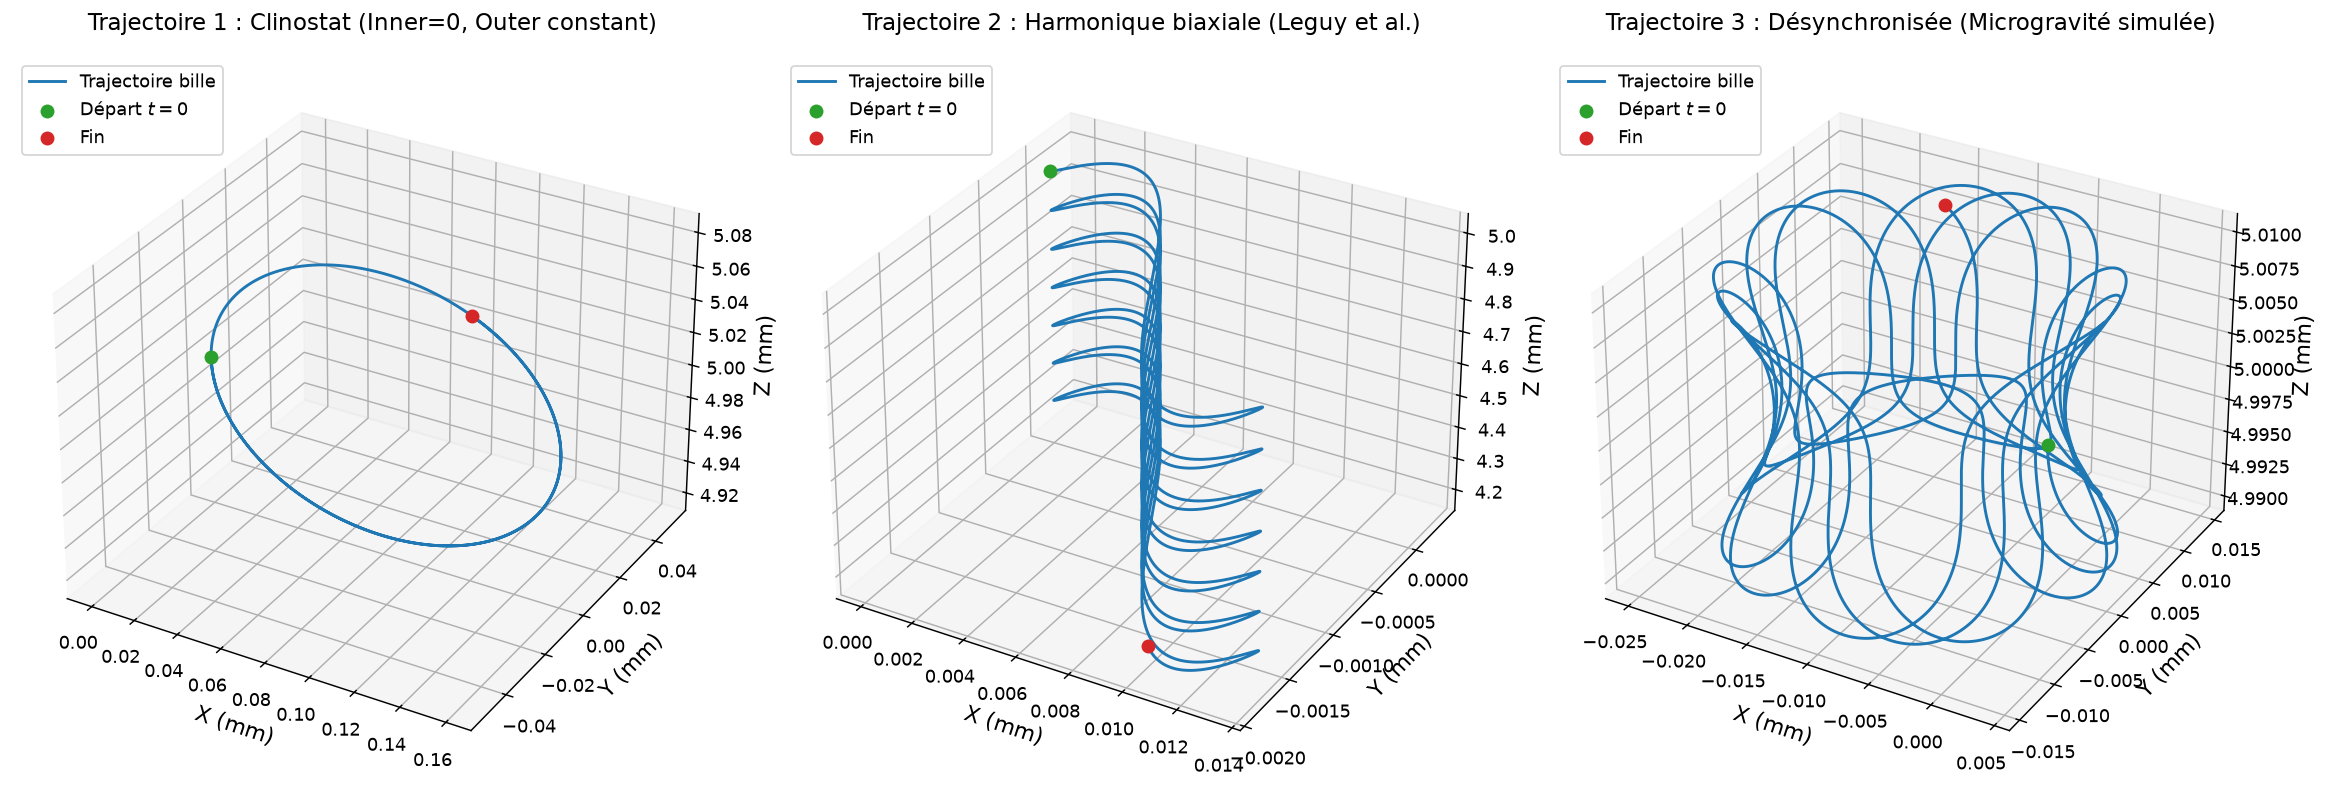

In [15]:
n_trajs = len(results)
fig = plt.figure(figsize=(6 * n_trajs, 6))

for idx, (title, res) in enumerate(results.items(), 1):
    ax = fig.add_subplot(1, n_trajs, idx, projection="3d")
    r_mm = res["r"] * 1e3

    # Trajectoire complète
    ax.plot(
        r_mm[:, 0],
        r_mm[:, 1],
        r_mm[:, 2],
        color="#1f77b4",
        label="Trajectoire bille",
    )

    # Marqueurs de départ et fin
    ax.scatter(
        r_mm[0, 0],
        r_mm[0, 1],
        r_mm[0, 2],
        color="#2ca02c",
        s=45,
        label="Départ $t=0$",
        zorder=5,
    )
    ax.scatter(
        r_mm[-1, 0],
        r_mm[-1, 1],
        r_mm[-1, 2],
        color="#d62728",
        s=45,
        label="Fin",
        zorder=5,
    )

    ax.set_title(title, pad=15)
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")
    ax.legend(loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

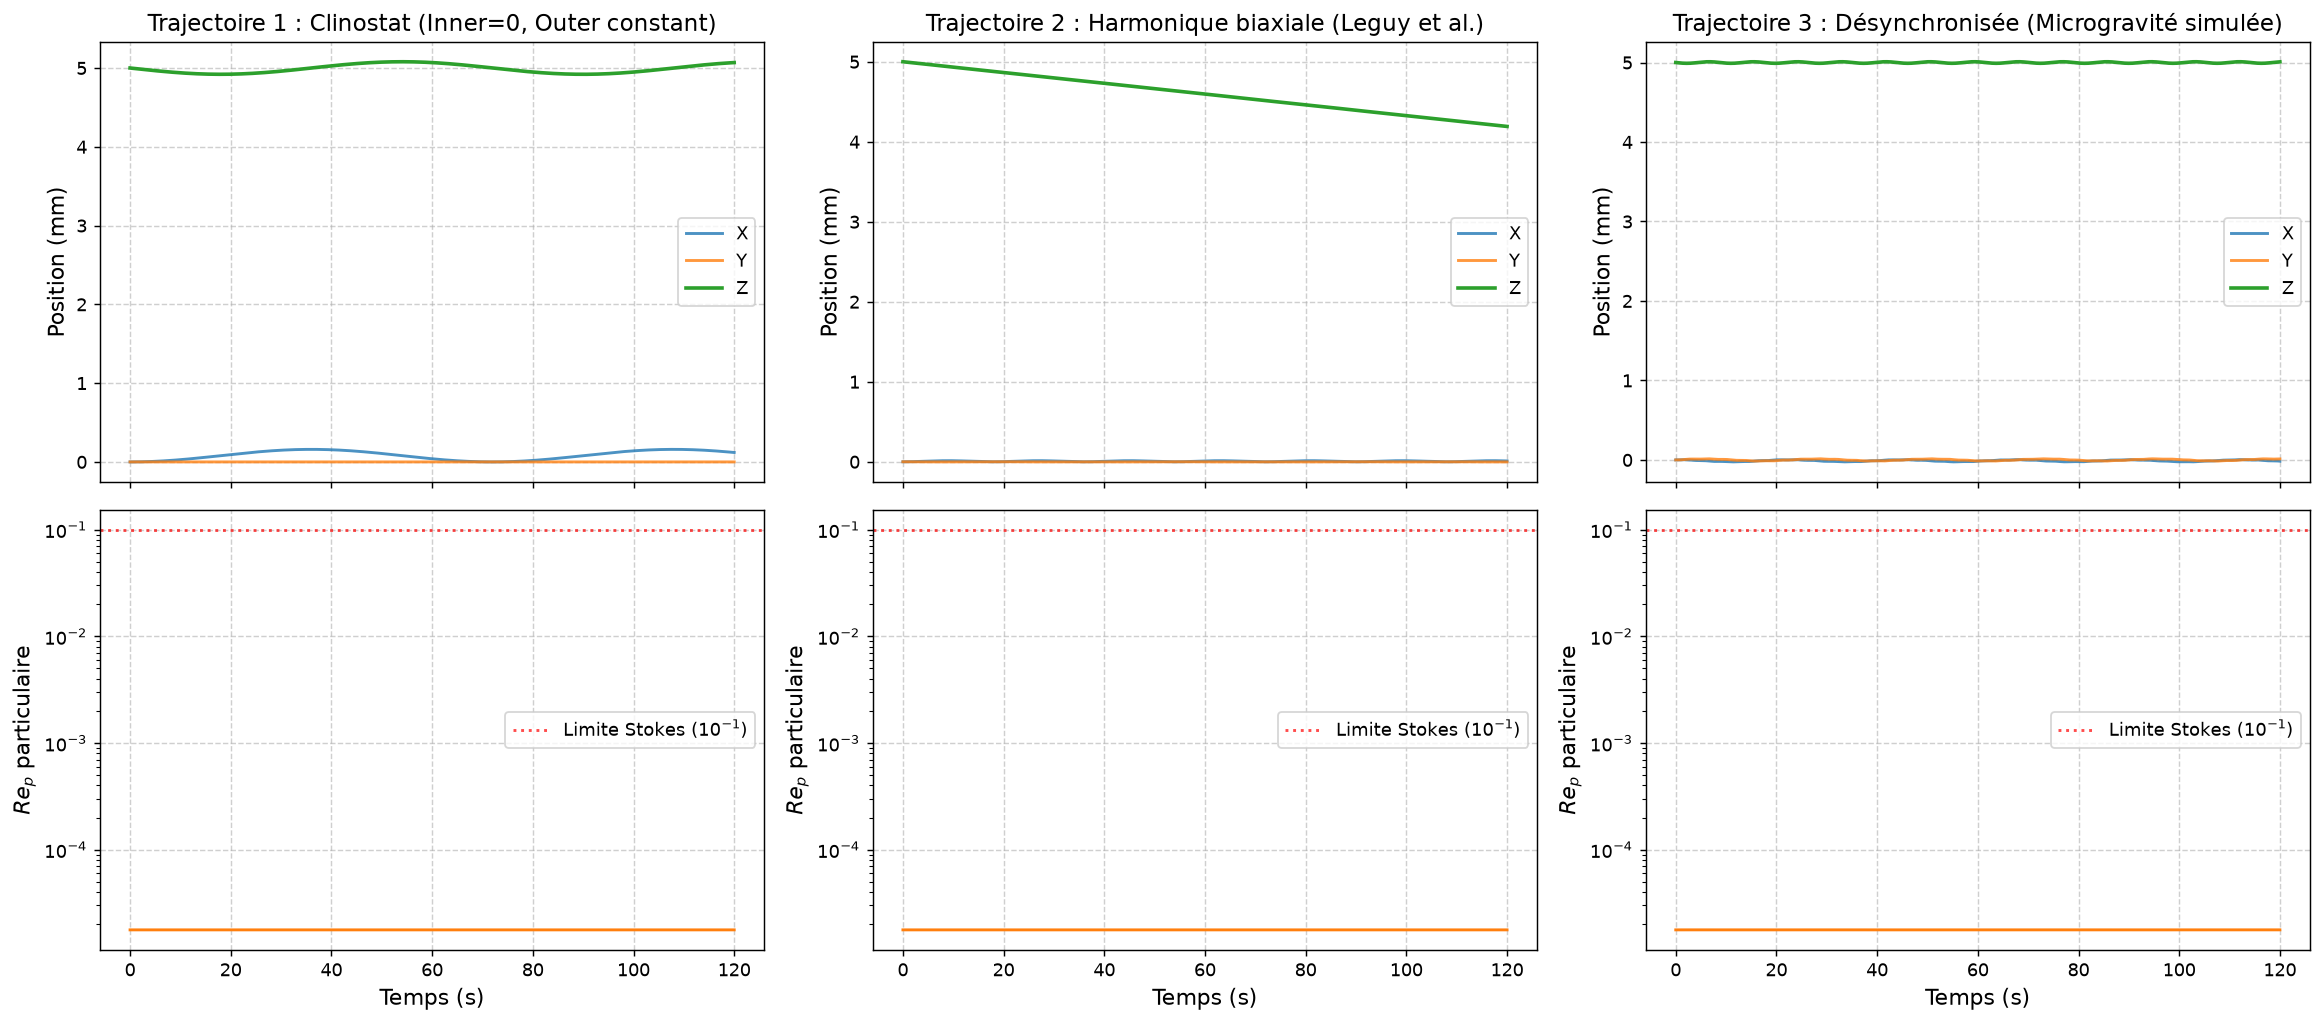

In [ ]:
fig, axes = plt.subplots(2, n_trajs, figsize=(6 * n_trajs, 8), sharex=True)

for idx, (title, res) in enumerate(results.items()):
    t = res["time"]
    r_mm = res["r"] * 1e3
    col_ax0 = axes[0, idx] if n_trajs > 1 else axes[0]
    col_ax1 = axes[1, idx] if n_trajs > 1 else axes[1]

    # Évolution des coordonnées cartésiennes
    col_ax0.plot(t, r_mm[:, 0], label="X", alpha=0.8)
    col_ax0.plot(t, r_mm[:, 1], label="Y", alpha=0.8)
    col_ax0.plot(t, r_mm[:, 2], label="Z", linewidth=2.0)
    col_ax0.set_title(title)
    col_ax0.set_ylabel("Position (mm)")
    col_ax0.grid(True, linestyle="--", alpha=0.6)
    col_ax0.legend(loc="best")

    # Évolution du Reynolds particulaire (échelle log)
    col_ax1.plot(t, res["re_p"], color="#ff7f0e")
    col_ax1.set_yscale("log")
    col_ax1.set_xlabel("Temps (s)")
    col_ax1.set_ylabel(r"$Re_p$ particulaire")
    col_ax1.axhline(
        0.1,
        color="red",
        linestyle=":",
        alpha=0.7,
        label="Limite Stokes ($10^{-1}$)",
    )
    col_ax1.grid(True, linestyle="--", alpha=0.6)
    col_ax1.legend(loc="best")

plt.tight_layout()
plt.show()